In [49]:
import pandas as pd
from utility import _process_data, _turnup_data, setpoint_df, _summary_cost_plot, make_model_cost
from datetime import date, timedelta
import plotly.io as pio
from pathlib import Path
import pickle

turnup_data = _turnup_data(True, "", None, setpoint_df, False)
turnup_data["concentration_starch"]=((turnup_data["Flow_starch_main_line_to_working_tank_1~^0"] + turnup_data["Flow_starch_main_line_to_working_tank_2~^0"])/
                                                       (turnup_data["Dilution_water_working_tank_2"]+turnup_data["Dilution_water_working_tank_1"]+
                                                        turnup_data["Flow_starch_main_line_to_working_tank_1~^0"] + turnup_data["Flow_starch_main_line_to_working_tank_2~^0"]))
turnup_data["Fibre__g/m2_"]= turnup_data["Current_basis_weight"]*(1-turnup_data["Current_reel_moisture_average(reel)"]/100)-turnup_data["Starch_uptake__g/m2_"]                                            

<Axes: >

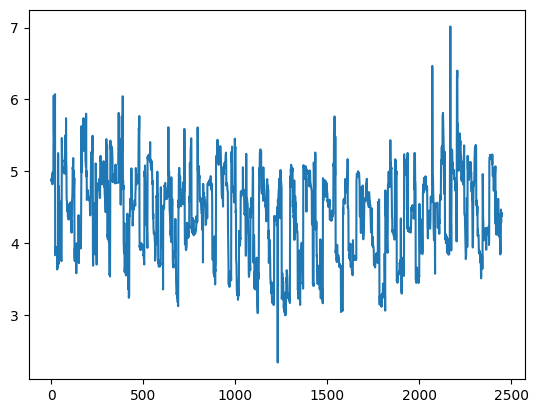

In [57]:
turnup_data["Starch_uptake__g/m2_"].plot()

In [2]:
response_vars=[
 "MBS_SCT_CD"
]

In [50]:
control_vars = [
    "Current_basis_weight",
    "Fibre__g/m2_",
    "Starch_uptake__g/m2_",
    #"Current_reel_moisture_average(reel)",
    "Actual_moisture",
    "Jet/wire_ratio",

    "Draw_PD5-SS",
    "Draw_PS-PD1", #Pre-dryer
    "Draw_PD2-PD3", #Pre-dryer
    "Draw_PD4-PD5", #Pre-dryer 
    "Draw_PD3-PD4", #Pre-dryer 
    "Draw_PD1-PD2", #Pre-dryer
    "Moisture_out_of_PreDryer", #Pre-dryer

    "Draw_WS-PS", # Press Section
    "PickUp_Tension", # Press Section
    "Vacuum_presszone_of_suction-press_roll", # Press Section
    "Vacuum_uhle-box_Pick-Up", # Press Section
    "Vacuum_uhle-box_bottom_felt", # Press Section
    "Linepressure_1st_press_FS__bar_", # Press Section
    "Linepressure_2nd_press_FS__bar_", # Press Section
    "Linepressure_1st_press_DS__bar_", # Press Section
    "Linepressure_2nd_press_DS__bar_", # Press Section 
    "Linepressure_shoe_press__bar_", # Press Section 

    "Dewatering_top_wire_suction_box_zone_2", # Forming Wire
    "Vacuum_suction_box_9", 
    "Vacuum_wet_suction_box", # Forming Wire
    "Vacuum_sheet_seperator_box", # Forming Wire
    "Vacuum_suction_box_10", # Forming Wire
    "Vacuum_suction_box_11", # Forming Wire
    "Vacuum_wire_suction_box_1", # Forming Wire
    "Vacuum_wire_suction_box_2", # Forming Wire
    "Consistency_white_water", # Forming Wire
    "White_water_temperature", # Forming Wire
    "Conductivity_white_water_B46", # Forming Wire
    "Top_wire_tenstion", # Forming Wire
    "pH_measurement_white_water_B41", # Forming Wire

     "Lip_settings", # Headbox

    "Retention_Aid_mass_flow__g/T_", # Approach Flow
    "Bentonite_1_mass_flow__g/T_", # Approach Flow
    "Bentonite_2_mass_flow__g/T_", # Approach Flow
    "Thick_Stock_Consistency__%_", # Approach Flow

    "fibre_short/long",
    "concentration_starch",
    'Speed_Size_Press',
    'Rod_Pressure_Bottom_Roll',
    'Rod_pressure_Top_Roll',

    #'Steam_flow_to_AfterDryers',
    #'Steam_flow_to_PreDryers',
]

# Bnlearn

In [52]:
import numpy as np
import pandas as pd
import bnlearn as bn
from sklearn.preprocessing import KBinsDiscretizer
 
df = turnup_data[control_vars+response_vars].copy()
 
# 1) Discretize all numeric columns into quantile bins
num_cols = df.select_dtypes(include=[np.number]).columns
 
kbd = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile")
Xb = kbd.fit_transform(df[num_cols])
 
df_disc = df.copy()
df_disc[num_cols] = Xb
 
# 2) Make them categorical (bnlearn likes discrete categories)
for c in num_cols:
    df_disc[c] = df_disc[c].astype(int).astype(str)   # "0","1","2","3","4"
 
# 3) Learn BN structure on discretized data
model0 = bn.structure_learning.fit(df_disc, methodtype="hillclimbsearch", scoretype="bic")
print("Edges after structure learning:", len(model0["model_edges"]))
 
# 4) Optional pruning (now chi-square makes sense)
model = bn.independence_test(model0, df_disc, test="chi_square", alpha=0.10, prune=True)
print("Edges after prune:", len(model["model_edges"]))
 
target = "MBS_SCT_CD"
 
edges = model["model_edges"]  # list of (u,v)
kept_edges = [(u, v) for (u, v) in edges if v == target]
 
model_target = model.copy()
model_target["model_edges"] = kept_edges
 
bn.plot(model_target, interactive=True)

[bnlearn] >Computing best DAG using [hillclimbsearch]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
Edges after structure learning: 64
[bnlearn] >Compute edge strength with [chi_square]


INFO:d3blocks.d3blocks:Cleaning edge_properties and config parameters..
[23-01-2026 14:43:53] [d3graph.d3graph] [INFO] Converting source-target into adjacency matrix..
[23-01-2026 14:43:53] [d3graph.d3graph] [INFO] Making the matrix symmetric..
[23-01-2026 14:43:53] [d3graph.d3graph] [INFO] Set directed=True to see the markers!
[23-01-2026 14:43:53] [d3graph.d3graph] [INFO] Keep only edges with weight>0
[23-01-2026 14:43:53] [d3graph.d3graph] [INFO] Converting source-target into adjacency matrix..
[23-01-2026 14:43:53] [d3graph.d3graph] [INFO] Making the matrix symmetric..
[23-01-2026 14:43:53] [d3graph.d3graph] [INFO] Converting adjacency matrix into source-target..
[23-01-2026 14:43:53] [d3graph.d3graph] [INFO] Number of unique nodes: %.0d
[23-01-2026 14:43:53] [d3graph.d3graph] [INFO] Slider range is set to [0, 5]


Edges after prune: 64
[bnlearn] >Set node properties.
[bnlearn]> Set edge weights based on the [chi_square] test statistic.
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Set edge properties.


[23-01-2026 14:43:54] [d3graph.d3graph] [INFO] Write to path: [C:\Users\gbmiggon\AppData\Local\Temp\d3graph\d3graph.html]
[23-01-2026 14:43:54] [d3graph.d3graph] [INFO] File already exists and will be overwritten: [C:\Users\gbmiggon\AppData\Local\Temp\d3graph\d3graph.html]
[23-01-2026 14:43:54] [d3graph.d3graph] [INFO] Keep only edges with weight>0
[23-01-2026 14:43:54] [d3graph.d3graph] [INFO] Converting source-target into adjacency matrix..
[23-01-2026 14:43:54] [d3graph.d3graph] [INFO] Making the matrix symmetric..
[23-01-2026 14:43:54] [d3graph.d3graph] [INFO] Number of unique nodes: %.0d
[23-01-2026 14:43:54] [d3graph.d3graph] [INFO] Slider range is set to [0, 5]
[23-01-2026 14:43:54] [d3graph.d3graph] [INFO] Write to path: [C:\Users\gbmiggon\AppData\Local\Temp\d3graph\bnlearn_Directed_Acyclic_Graph_(DAG).html]
[23-01-2026 14:43:54] [d3graph.d3graph] [INFO] File already exists and will be overwritten: [C:\Users\gbmiggon\AppData\Local\Temp\d3graph\bnlearn_Directed_Acyclic_Graph_(DA

{'fig': 'C:\\Users\\gbmiggon\\AppData\\Local\\Temp\\d3graph\\bnlearn_Directed_Acyclic_Graph_(DAG).html',
 'ax': 'C:\\Users\\gbmiggon\\AppData\\Local\\Temp\\d3graph\\bnlearn_Directed_Acyclic_Graph_(DAG).html',
 'pos': None,
 'G': <networkx.classes.digraph.DiGraph at 0x1fac77e8b50>,
 'node_properties': {'Current_basis_weight': {'node_color': '#ADD8E6',
   'node_size': 10},
  'Fibre__g/m2_': {'node_color': '#ADD8E6', 'node_size': 10},
  'Starch_uptake__g/m2_': {'node_color': '#ADD8E6', 'node_size': 10},
  'Actual_moisture': {'node_color': '#ADD8E6', 'node_size': 10},
  'Jet/wire_ratio': {'node_color': '#ADD8E6', 'node_size': 10},
  'Draw_PD5-SS': {'node_color': '#ADD8E6', 'node_size': 10},
  'Draw_PS-PD1': {'node_color': '#ADD8E6', 'node_size': 10},
  'Draw_PD2-PD3': {'node_color': '#ADD8E6', 'node_size': 10},
  'Draw_PD4-PD5': {'node_color': '#ADD8E6', 'node_size': 10},
  'Draw_PD3-PD4': {'node_color': '#ADD8E6', 'node_size': 10},
  'Draw_PD1-PD2': {'node_color': '#ADD8E6', 'node_size': 

In [53]:
model_target = bn.parameter_learning.fit(model_target, df_disc)

[bnlearn] >Parameter learning> Computing parameters using [bayes]
[bnlearn] >Converting [<class 'pgmpy.base.DAG.DAG'>] to BayesianNetwork model.
[bnlearn] >Converting adjmat to BayesianNetwork.
[bnlearn] >CPD of Current_basis_weight:
+-------------------------+-----+---------------------+
| Actual_moisture         | ... | Actual_moisture(4)  |
+-------------------------+-----+---------------------+
| Current_basis_weight(0) | ... | 0.06222865412445731 |
+-------------------------+-----+---------------------+
| Current_basis_weight(1) | ... | 0.06367583212735166 |
+-------------------------+-----+---------------------+
| Current_basis_weight(2) | ... | 0.4515195369030391  |
+-------------------------+-----+---------------------+
| Current_basis_weight(3) | ... | 0.36034732272069464 |
+-------------------------+-----+---------------------+
| Current_basis_weight(4) | ... | 0.06222865412445731 |
+-------------------------+-----+---------------------+
[bnlearn] >CPD of Fibre__g/m2_:
+-----

In [43]:
for cpd in model_target['model'].get_cpds():
    print(cpd)
    print()

+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+

+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+
| ... |
+-----+

+----------------------------+-----+-------------------------------+
| Current_basis_weight       | ... | Current_basis_weight(4)       |
+----------------------------+-----+-------------------------------+
| SpeedSizer_Linepressure_FS | ... | SpeedSizer_Linepressure_FS(4) |
+----------------------------+-----+-------------------------------+
| Draw_PD5-SS(0)             | ... | 0.058823529411764705          |
+----------------------------+-----+-------------------------------+
| Draw_PD5-SS(1)             | ... | 0.08235294117647059           |
+----------------------------+-----+-------------------------------+
| Draw_PD5-SS(2)             | ... | 0.28823529411764703           |
+----------------------------+-----+-------------------------------+
| Draw_PD5-SS(3

In [60]:
model_target = bn.parameter_learning.fit(model_target, df_disc, methodtype="bayes")

[bnlearn] >Parameter learning> Computing parameters using [bayes]


[bnlearn] >CPD of Current_basis_weight:
+-------------------------+-----+---------------------+
| Actual_moisture         | ... | Actual_moisture(4)  |
+-------------------------+-----+---------------------+
| Current_basis_weight(0) | ... | 0.06222865412445731 |
+-------------------------+-----+---------------------+
| Current_basis_weight(1) | ... | 0.06367583212735166 |
+-------------------------+-----+---------------------+
| Current_basis_weight(2) | ... | 0.4515195369030391  |
+-------------------------+-----+---------------------+
| Current_basis_weight(3) | ... | 0.36034732272069464 |
+-------------------------+-----+---------------------+
| Current_basis_weight(4) | ... | 0.06222865412445731 |
+-------------------------+-----+---------------------+
[bnlearn] >CPD of Fibre__g/m2_:
+----------------------+-----+-------------------------+
| Current_basis_weight | ... | Current_basis_weight(4) |
+----------------------+-----+-------------------------+
| Fibre__g/m2_(0)      | ... 

In [ ]:
import matplotlib.pyplot as plt

model_params = bn.parameter_learning.fit(model_target, df_disc)
  
print("Possible values of Starch_uptake__g/m2_:", df_disc["Starch_uptake__g/m2_"].unique())

# Query inference for each value of Starch_uptake__g/m2_
results = {}
for starch_value in sorted(df_disc["Starch_uptake__g/m2_"].unique()):
    query = bn.inference.fit(
        model_params,
        variables=[target],
        evidence={"Starch_uptake__g/m2_": starch_value}
    )
    results[starch_value] = query.df
    print(f"\nP(MBS_SCT_CD | Starch_uptake__g/m2_ = {starch_value}):")
    print(query.df)

fig, ax = plt.subplots(figsize=(10, 6))
for starch_val, prob_df in results.items():
    ax.plot(prob_df.index, prob_df['p'], marker='o', label=f'Starch={starch_val}')

ax.set_xlabel('MBS_SCT_CD (discretized bins)')
ax.set_ylabel('Probability')
ax.set_title('Effect of Starch_uptake__g/m2_ on MBS_SCT_CD')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

[bnlearn] >Parameter learning> Computing parameters using [bayes]


[bnlearn] >CPD of Current_basis_weight:
+-------------------------+-----+---------------------+
| Actual_moisture         | ... | Actual_moisture(4)  |
+-------------------------+-----+---------------------+
| Current_basis_weight(0) | ... | 0.06222865412445731 |
+-------------------------+-----+---------------------+
| Current_basis_weight(1) | ... | 0.06367583212735166 |
+-------------------------+-----+---------------------+
| Current_basis_weight(2) | ... | 0.4515195369030391  |
+-------------------------+-----+---------------------+
| Current_basis_weight(3) | ... | 0.36034732272069464 |
+-------------------------+-----+---------------------+
| Current_basis_weight(4) | ... | 0.06222865412445731 |
+-------------------------+-----+---------------------+
[bnlearn] >CPD of Fibre__g/m2_:
+----------------------+-----+-------------------------+
| Current_basis_weight | ... | Current_basis_weight(4) |
+----------------------+-----+-------------------------+
| Fibre__g/m2_(0)      | ... 

NameError: name 'plt' is not defined